Epoch 1/150
240/240 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - AUC: 0.4510 - Precision: 0.1699 - Recall: 0.3118 - accuracy: 0.5437 - loss: 0.7406 - val_AUC: 0.6435 - val_Precision: 0.5833 - val_Recall: 0.0427 - val_accuracy: 0.7975 - val_loss: 0.5110
Epoch 2/150
240/240 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - AUC: 0.5915 - Precision: 0.3401 - Recall: 0.1321 - accuracy: 0.7713 - loss: 0.5251 - val_AUC: 0.7354 - val_Precision: 0.0000e+00 - val_Recall: 0.0000e+00 - val_accuracy: 0.7950 - val_loss: 0.4564
Epoch 3/150
240/240 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - AUC: 0.6407 - Precision: 0.4306 - Recall: 0.0714 - accuracy: 0.7969 - loss: 0.4838 - val_AUC: 0.7671 - val_Precision: 0.7222 - val_Recall: 0.0793 - val_accuracy: 0.8050 - val_loss: 0.4366
Epoch 4/150
240/240 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - AUC: 0.7003 - Precision: 0.5110 - Recall: 0.1438 - accuracy: 0.7988 - loss: 0.4631 - val_AUC: 0.7889 - val_Precision: 0.7714 - val_Recall: 0.1646 - val_accuracy: 0.8188 - val_loss: 0.4243
Epoch 5/150
240/240 

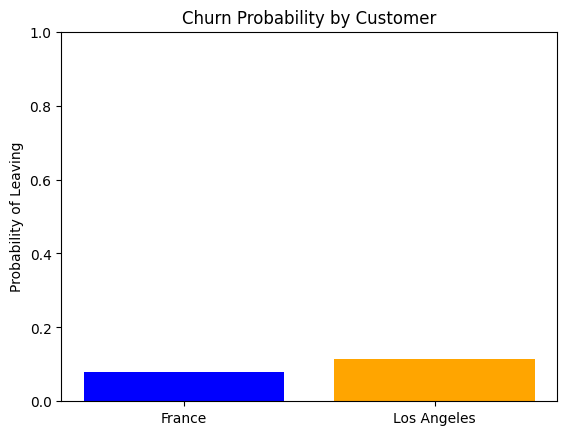

Confusion Matrix:
[[1561   34]
 [ 284  121]]
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  

Model Performance Metrics:
Accuracy: 84.10%
Precision: 78.06%
Recall: 29.88%
F1-Score: 43.21%
ROC-AUC: 85.06%
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  


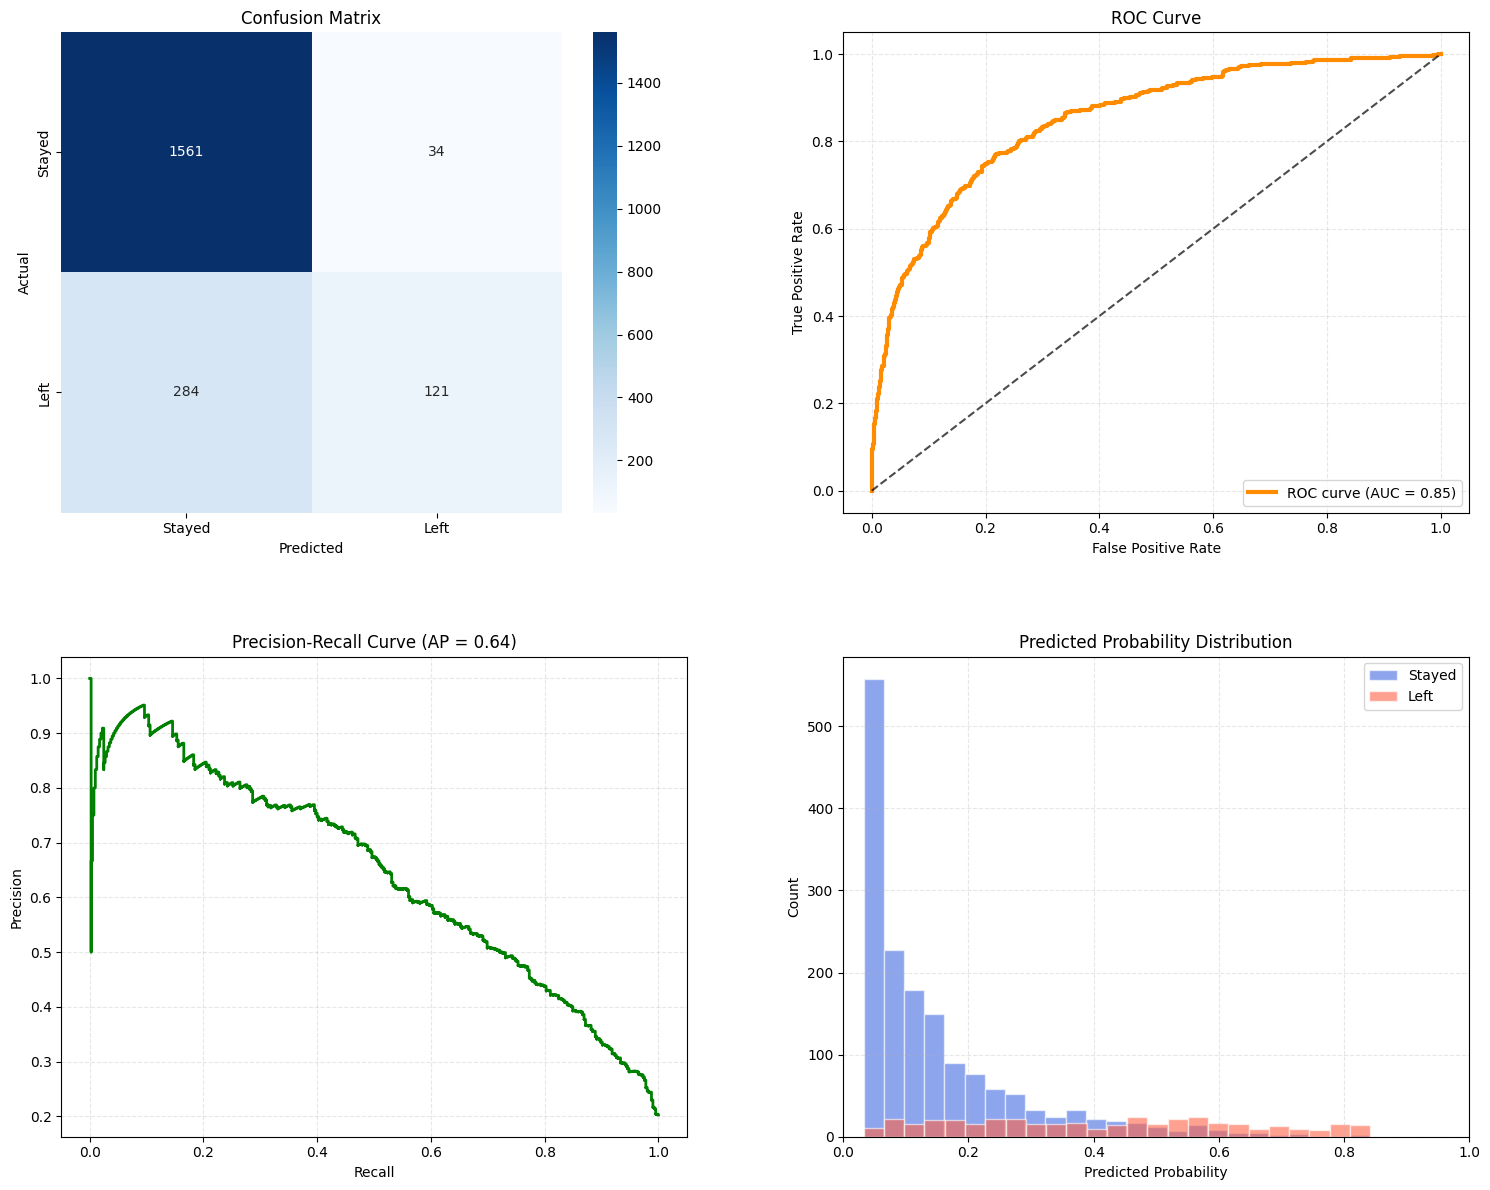

In [13]:
# Artificial Neural Network for Churn Prediction

# Part 1 - Data Preprocessing

# Importing the libraries
import os
os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from google.colab import files
"""
def upload_dataset():
    print("📂 Please upload your dataset (e.g., Churn_Modelling.csv)")
    uploaded = files.upload()  # opens file dialog in Colab
    for filename in uploaded.keys():
        dataset = pd.read_csv(filename)
        print(f"\n✅ Dataset '{filename}' uploaded successfully!")
        return dataset
"""
# Importing the dataset
dataset = pd.read_csv('Churn_Modelling.csv')
#dataset = upload_dataset()


X = dataset.iloc[:, 3:13].values   # Independent variables
y = dataset.iloc[:, 13].values     # Dependent variable (Exited)

# Encoding categorical data
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer

# Encoding 'Geography' column
labelencoder_X_1 = LabelEncoder()
X[:, 1] = labelencoder_X_1.fit_transform(X[:, 1])

# Encoding 'Gender' column
labelencoder_X_2 = LabelEncoder()
X[:, 2] = labelencoder_X_2.fit_transform(X[:, 2])

# OneHotEncoding 'Geography' to avoid giving numeric order
columnTransformer = ColumnTransformer(
    [('encoder', OneHotEncoder(), [1])],
    remainder='passthrough'
)
X = np.array(columnTransformer.fit_transform(X), dtype=np.float64)

# Avoid dummy variable trap by dropping the first dummy variable
X = X[:, 1:]

# Splitting the dataset into the Training set and Test set
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0
)

# Feature Scaling
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

# Part 2 - Building the ANN

# Importing the Keras libraries and packages
from keras.models import Sequential
from keras.layers import Dense, Dropout, Input
from keras.callbacks import EarlyStopping
# from sklearn.metrics import roc_curve

# Initialising the ANN
classifier = Sequential()

# Improved ANN Architecture (with tuned parameters)
classifier.add(Input(shape=(11,)))                   # Input layer
classifier.add(Dense(8, activation='tanh'))          # Increased neurons from 6 to 8
classifier.add(Dropout(0.3))                         # Dropout for regularization
classifier.add(Dense(8, activation='tanh'))          # Second hidden layer (also 8 neurons)
classifier.add(Dropout(0.3))
classifier.add(Dense(1, activation='sigmoid'))       # Output layer

# Compiling the ANN
classifier.compile(optimizer='rmsprop',
                   loss='binary_crossentropy',
                   metrics=['accuracy', 'Precision', 'Recall', 'AUC'])

# Stop training early if validation loss does not improve for 10 epochs
# and restore the weights from the best epoch to prevent overfitting
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Fitting the ANN to the Training set
classifier.fit(X_train, y_train, batch_size=30, epochs=150, validation_split=0.1, callbacks=[early_stop])

"""
# Predicted probabilities
y_pred_prob = classifier.predict(X_test)

# Compute ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)

# Compute Youden’s J statistic (tpr - fpr)
J = tpr - fpr
best_idx = J.argmax()
best_threshold = thresholds[best_idx]

print("Optimal Threshold:", best_threshold)
"""
# Part 3 - Making predictions and evaluating the model

# Predicting the Test set results
y_pred = classifier.predict(X_test)
y_pred = (y_pred > 0.56)

# Combined customers
new_customers = np.array([
    [0.0, 0, 600, 1, 40, 3, 60000, 2, 1, 1, 50000],   # France, Male
    [0.0, 0, 800, 0, 40, 2, 120000, 1, 0, 1, 70000]   # Los Angeles, Female
])

# Apply same scaling as training data
new_customer_scaled = sc.transform(new_customers)
new_prediction = classifier.predict(new_customer_scaled)
new_prediction = (new_prediction > 0.56)

print(f"Customer 1 (France) will leave?: {new_prediction[0]}")
print(f"Customer 2 (Los Angeles) will leave?: {new_prediction[1]}")

# Churn probabilities
churn_probs = classifier.predict(new_customer_scaled)
plt.bar(['France', 'Los Angeles'], churn_probs.flatten(), color=['blue', 'orange'])
plt.title('Churn Probability by Customer')
plt.ylabel('Probability of Leaving')
plt.ylim(0, 1)
plt.show()


# Making the Confusion Matrix
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

# Calculate metrics for display
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, ConfusionMatrixDisplay, confusion_matrix, roc_curve, auc, precision_recall_curve
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, classifier.predict(X_test))


# Evaluate performance on test set
y_pred_prob = classifier.predict(X_test)
y_pred = (y_pred_prob > 0.56)

print("\nModel Performance Metrics:")
print("Accuracy: {:.2f}%".format(accuracy_score(y_test, y_pred) * 100))
print("Precision: {:.2f}%".format(precision_score(y_test, y_pred) * 100))
print("Recall: {:.2f}%".format(recall_score(y_test, y_pred) * 100))
print("F1-Score: {:.2f}%".format(f1_score(y_test, y_pred) * 100))
print("ROC-AUC: {:.2f}%".format(roc_auc_score(y_test, y_pred_prob) * 100))


# --- Predicted probabilities and threshold ---
from sklearn.metrics import average_precision_score

ap = average_precision_score(y_test, y_pred_prob)
optimal_threshold = 0.56
y_pred_prob = classifier.predict(X_test)
y_pred_opt = (y_pred_prob >= optimal_threshold)

# --- Confusion Matrix ---
cm = confusion_matrix(y_test, y_pred_opt)

# --- ROC Curve ---
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)

# --- Precision-Recall Curve ---
precision, recall, _ = precision_recall_curve(y_test, y_pred_prob)

# --- Probability Distribution ---
prob_stayed = y_pred_prob[y_test==0]
prob_left = y_pred_prob[y_test==1]

# --- Create a 2x2 Dashboard ---
fig, axs = plt.subplots(2, 2, figsize=(15, 12))

# 1️⃣ Confusion Matrix Heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Stayed', 'Left'], yticklabels=['Stayed', 'Left'],
            ax=axs[0,0])
axs[0,0].set_title('Confusion Matrix')
axs[0,0].set_xlabel('Predicted')
axs[0,0].set_ylabel('Actual')


# 2️⃣ ROC Curve
axs[0,1].plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.2f})', color='darkorange', lw=3)
axs[0,1].plot([0, 1], [0, 1], 'k--', lw=1.5, alpha=0.7)
axs[0,1].grid(True, linestyle='--', alpha=0.3)
axs[0,1].set_xlabel('False Positive Rate')
axs[0,1].set_ylabel('True Positive Rate')
axs[0,1].set_title('ROC Curve')
axs[0,1].legend(loc='lower right')

# 3️⃣ Precision-Recall Curve
axs[1,0].step(recall, precision, where='post', color='green', lw=2)
axs[1,0].grid(True, linestyle='--', alpha=0.3)
axs[1,0].set_xlabel('Recall')
axs[1,0].set_ylabel('Precision')
axs[1,0].set_title(f'Precision-Recall Curve (AP = {ap:.2f})')

# 4️⃣ Predicted Probability Distribution
axs[1,1].hist(prob_stayed, bins=25, alpha=0.6, label='Stayed', color='royalblue', edgecolor='white')
axs[1,1].hist(prob_left, bins=25, alpha=0.6, label='Left', color='tomato', edgecolor='white')
axs[1,1].set_xlim(0, 1)
axs[1,1].grid(True, linestyle='--', alpha=0.3)
axs[1,1].set_xlabel('Predicted Probability')
axs[1,1].set_ylabel('Count')
axs[1,1].set_title('Predicted Probability Distribution')
axs[1,1].legend()

plt.tight_layout()
plt.subplots_adjust(wspace=0.25, hspace=0.3)
plt.show()





📂 Please upload your dataset (e.g., Churn_Modelling.csv)


Saving Churn_Modelling.csv to Churn_Modelling.csv

✅ Dataset 'Churn_Modelling.csv' uploaded successfully!
   RowNumber  CustomerId   Surname  CreditScore Geography  Gender  Age  \
0          1    15634602  Hargrave          619    France  Female   42   
1          2    15647311      Hill          608     Spain  Female   41   
2          3    15619304      Onio          502    France  Female   42   
3          4    15701354      Boni          699    France  Female   39   
4          5    15737888  Mitchell          850     Spain  Female   43   

   Tenure    Balance  NumOfProducts  HasCrCard  IsActiveMember  \
0       2       0.00              1          1               1   
1       1   83807.86              1          0               1   
2       8  159660.80              3          1               0   
3       1       0.00              2          0               0   
4       2  125510.82              1          1               1   

   EstimatedSalary  Exited  
0        101348.88     

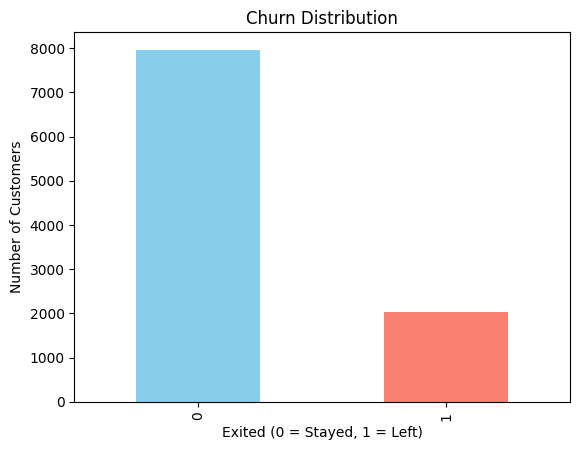

In [ ]:
# --- Dataset Upload and Basic Info ---
from google.colab import files
import pandas as pd


def upload_dataset():
    print("📂 Please upload your dataset (e.g., Churn_Modelling.csv)")
    uploaded = files.upload()  # opens file dialog in Colab
    for filename in uploaded.keys():
        dataset = pd.read_csv(filename)
        print(f"\n✅ Dataset '{filename}' uploaded successfully!")

        return dataset



# dataset = pd.read_csv('Churn_Modelling.csv')
dataset = upload_dataset()
X = dataset.iloc[:, 3:13].values
y = dataset.iloc[:, 13].values

print(dataset.head())
print(dataset.info())
print(dataset.describe())
print(dataset.corr(numeric_only=True))



import matplotlib.pyplot as plt
dataset['Exited'].value_counts().plot(kind='bar', color=['skyblue', 'salmon'])
plt.title('Churn Distribution')
plt.xlabel('Exited (0 = Stayed, 1 = Left)')
plt.ylabel('Number of Customers')
plt.show()


In [ ]:
!pip install tensorflow keras numpy pandas matplotlib seaborn scikit-learn scikeras joblib scipy threadpoolctl h5py


In [ ]:
import importlib

required_libs = [
    "tensorflow", "keras", "numpy", "pandas", "matplotlib", "seaborn",
    "sklearn", "scikeras", "joblib", "scipy", "threadpoolctl", "h5py"
]

for lib in required_libs:
    try:
        importlib.import_module(lib)
        print(f"✅ {lib} is installed.")
    except ImportError:
        print(f"❌ {lib} is missing. Install with: pip install {lib}")


✅ tensorflow is installed.
✅ keras is installed.
✅ numpy is installed.
✅ pandas is installed.
✅ matplotlib is installed.
✅ seaborn is installed.
✅ sklearn is installed.
✅ scikeras is installed.
✅ joblib is installed.
✅ scipy is installed.
✅ threadpoolctl is installed.
✅ h5py is installed.
